## Data Import

In [13]:
#Importing dataset and data dictionary csv files using pandas
import pandas as pd

dengue = pd.read_csv('Dengue_diseases_dataset_modified (1).csv')
datadict = pd.read_csv('data_dictionary.csv')

In [14]:
#Viewing the data dictionary to understand context for columns
print(datadict)

                   Column Name                                     Description
0                          age                     Age of the patient in years
1                       gender             Gender of the patient (Male/Female)
2              hemoglobin_g_dl  Hemoglobin level in grams per deciliter (g/dL)
3                    wbc_count   White blood cell count (cells per microliter)
4           differential_count             Differential white blood cell count
5                    rbc_count  Red blood cell count (millions per microliter)
6               platelet_count           Platelet count (cells per microliter)
7  platelet_distribution_width                Variation in platelet size (PDW)
8                 dengue_label     Target variable (0 = No Dengue, 1 = Dengue)


In [15]:
#Exploring basic attirbutes of the dataset
print("Shape:", dengue.shape)
print("Column Names:", dengue.columns.tolist())
print("Column Types:", dengue.dtypes)

Shape: (989, 9)
Column Names: ['age', 'gender', 'hemoglobin_g_dl', 'wbc_count', 'differential_count', 'rbc_count', 'platelet_count', 'platelet_distribution_width', 'dengue_label']
Column Types: age                              int64
gender                             str
hemoglobin_g_dl                float64
wbc_count                      float64
differential_count               int64
rbc_count                        int64
platelet_count                 float64
platelet_distribution_width    float64
dengue_label                     int64
dtype: object


In [16]:
dengue['dengue_label'].value_counts() 
#644 positive cases, 345 negative cases 
#~65% positive cases, 35% negative cases
#No need for resampling to balance the dataset, since there is not a large difference in positive vs. negative cases

dengue_label
1    644
0    345
Name: count, dtype: int64

In [17]:
dengue.isnull().sum()
#Some missing values in WBC count, platelet count, platelet distribution width columns
#Otherwise no missing values in other columns

age                             0
gender                          0
hemoglobin_g_dl                 0
wbc_count                      24
differential_count              0
rbc_count                       0
platelet_count                 16
platelet_distribution_width    19
dengue_label                    0
dtype: int64

In [18]:
#To view missingness in each column as a percentage
dengue.isnull().sum() / len(dengue) * 100  
#Less than 2.5% missing for all the missing variables

#Options to deal with missing data
#Remove rows with missing values from dataset - a possibility since only a small percentage of rows have missing data
#Fill missing values with the column mean - prevents us from losiing data, but may skew these observations
#KNN imputation - impute data using the K nearest neighbors algorithm, which can be more accurate than mean imputation but is more complex to implement

#Decision - KNN imputation



age                            0.000000
gender                         0.000000
hemoglobin_g_dl                0.000000
wbc_count                      2.426694
differential_count             0.000000
rbc_count                      0.000000
platelet_count                 1.617796
platelet_distribution_width    1.921132
dengue_label                   0.000000
dtype: float64

## Cleaning


In [19]:
#First, changing gender column to binary columns, rather than "Male", "Female", and "Child"
#Cannot use text based columns for analysis, need binary columns
dummies = pd.get_dummies(dengue['gender'], prefix=None).astype(int)
dengue = pd.concat([dengue, dummies], axis=1)
dengue = dengue.drop(columns=['gender'])


In [20]:
#KNN imputation
from sklearn.impute import KNNImputer

#Put it into a new dataframe, dengue_imputed, to preserve original
imputer = KNNImputer(n_neighbors=5)
dengue_imputed = pd.DataFrame(
    imputer.fit_transform(dengue),
    columns=dengue.columns
)

## Exploratory Data Analysis

<Axes: >

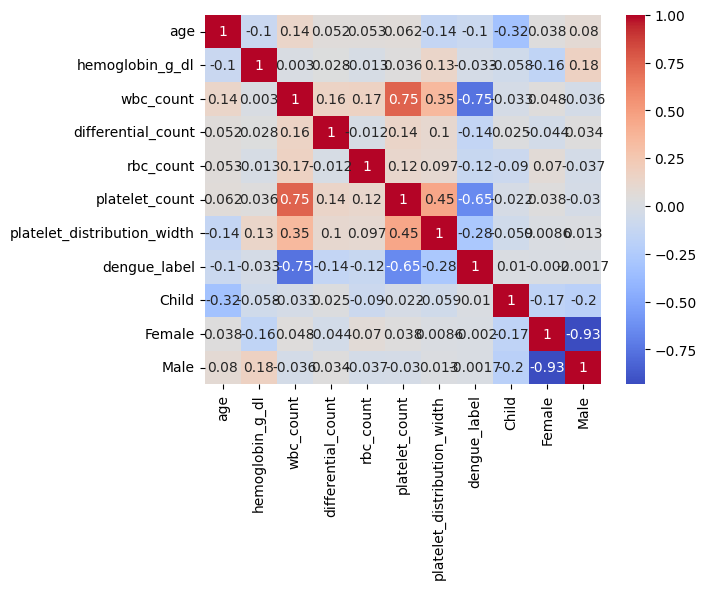

In [21]:
#First look at raw correlations

corr_matrix = dengue.corr(numeric_only=True)
import seaborn as sns
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

#Immediatley, WBC count and platelet count seem to be the most correlated with dengue fever. 
#Both negatively correlated - lower WBC count, higher chance of dengue

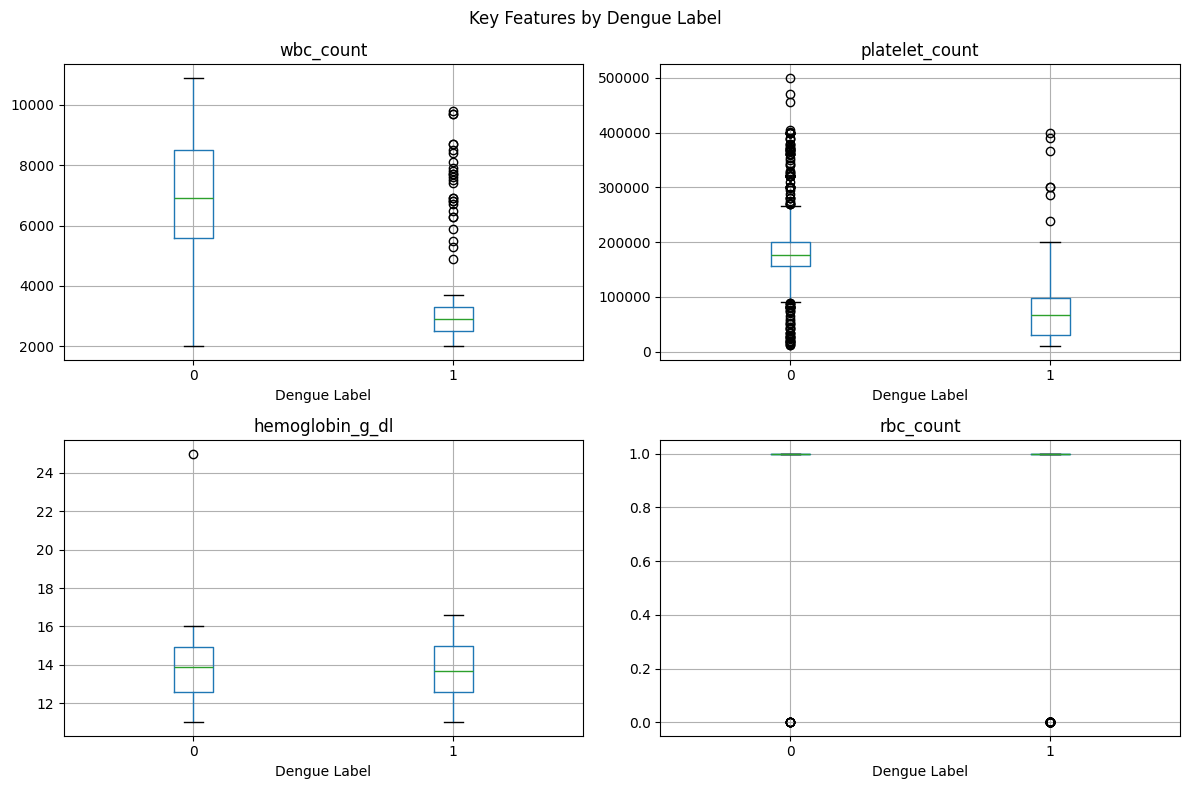

In [23]:
# Box plots of key features by dengue label

import matplotlib.pyplot as plt

features_to_plot = ['wbc_count', 'platelet_count', 'hemoglobin_g_dl', 'rbc_count']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, feature in zip(axes, features_to_plot):
    dengue.boxplot(column=feature, by='dengue_label', ax=ax)
    ax.set_title(feature)
    ax.set_xlabel('Dengue Label')

plt.suptitle('Key Features by Dengue Label')
plt.tight_layout()
plt.savefig('feature_boxplots.png', dpi=150)
plt.show()

## Logistic Regression
- The logistic regression is a classification algorithm that models the probability of a binary outcome using the sigmoid function to squash a linear combination of features into a value between 0 and 1. Coefficients are estimated by maximizing the likelihood of the observed data, and a decision threshold (typically 0.5) converts the predicted probability into a class label.
- Fast to train, highly interpretable coefficients
- Assumes a linear relationship between features and the log-odds of outcome, struggles with complex non-linear patterns
- Sensitive to correlated features and outliers
- Good baseline to compare other methods to

In [24]:
from sklearn.model_selection import train_test_split

X = dengue_imputed.drop(columns=['dengue_label'])  # features
y = dengue_imputed['dengue_label']                 # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

#rather poor performance

coefficients = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_[0]
})


              precision    recall  f1-score   support

         0.0       0.64      0.49      0.55       104
         1.0       0.68      0.80      0.74       144

    accuracy                           0.67       248
   macro avg       0.66      0.64      0.65       248
weighted avg       0.66      0.67      0.66       248



/Users/nickjeschke/Dengue/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [25]:
#coefficients
print(coefficients.sort_values('coefficient', ascending=False))

#hemoglobin the primary predictor, all else small by comparison

                       feature  coefficient
1              hemoglobin_g_dl     1.560385
4                    rbc_count     0.095839
3           differential_count     0.088338
8                       Female     0.052330
0                          age     0.041037
7                        Child     0.033737
9                         Male     0.032457
5               platelet_count    -0.000037
2                    wbc_count    -0.004022
6  platelet_distribution_width    -0.037626


## Random Forest
- Random Forest builds a large number of decision trees, each trained on a random bootstrap sample of the data with a random subset of features considered at each split. This decorrelation between trees is what reduces variance compared to a single tree. The final prediction is a majority vote across all trees, and feature importance is derived from how much each feature reduces impurity on average across all splits.
- Handles non-linear realtionships well, resistant to overfitting, handles missing data well
- Much slower to train than logistic regression, harder to interpret features

In [26]:
#Random forest classifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))

#Not much better

              precision    recall  f1-score   support

         0.0       0.66      0.50      0.57       104
         1.0       0.69      0.81      0.75       144

    accuracy                           0.68       248
   macro avg       0.68      0.66      0.66       248
weighted avg       0.68      0.68      0.67       248



In [27]:
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
})

print(importances.sort_values('importance', ascending=False))

#WBC count, platelet count, and platelet distribution width the most significant predictors

                       feature  importance
2                    wbc_count    0.519224
5               platelet_count    0.343521
6  platelet_distribution_width    0.112128
0                          age    0.012965
1              hemoglobin_g_dl    0.004668
4                    rbc_count    0.004007
3           differential_count    0.002495
8                       Female    0.000483
7                        Child    0.000374
9                         Male    0.000134


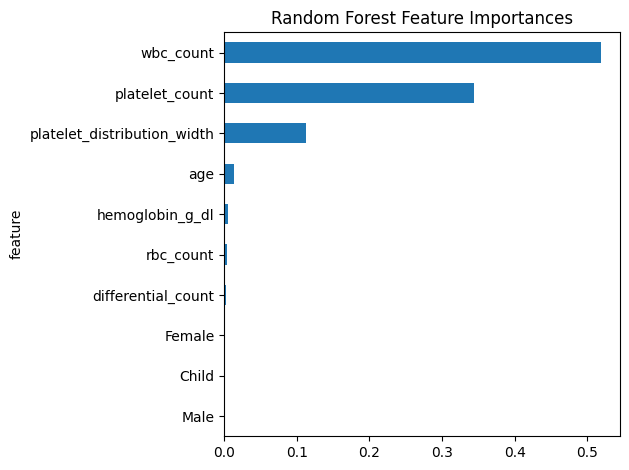

In [28]:
#Plotting features
import matplotlib.pyplot as plt
importances.sort_values('importance').plot(
    kind='barh', x='feature', y='importance', legend=False
)

plt.title('Random Forest Feature Importances')
plt.tight_layout()
plt.show()

## XGBoost
- XGBoost is a gradient boosting algorithm that builds trees sequentially (vs. Random Forest where they are build simultaneiously), where each new tree is fit to the residual errors of the current ensemble rather than the raw labels. It minimizes a regularized loss function using gradient descent, and includes built-in penalties on tree complexity to prevent overfitting.
- Often the best at tabular data, includes built in regularization, customizeable
- Computationally expensive, not very interpretable, can be prone to overfitting

In [29]:
#Running XGBOOST
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

xgb_model = XGBClassifier(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
print(classification_report(y_test, y_pred_xgb))
#not all that much better

              precision    recall  f1-score   support

         0.0       0.65      0.49      0.56       104
         1.0       0.69      0.81      0.75       144

    accuracy                           0.68       248
   macro avg       0.67      0.65      0.65       248
weighted avg       0.67      0.68      0.67       248



In [30]:
#Plotting important features
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
})
print(importances.sort_values('importance', ascending=False))

#WBC count by far the most important feature 

                       feature  importance
2                    wbc_count    0.959691
5               platelet_count    0.032943
6  platelet_distribution_width    0.006561
0                          age    0.000547
1              hemoglobin_g_dl    0.000258
3           differential_count    0.000000
4                    rbc_count    0.000000
7                        Child    0.000000
8                       Female    0.000000
9                         Male    0.000000


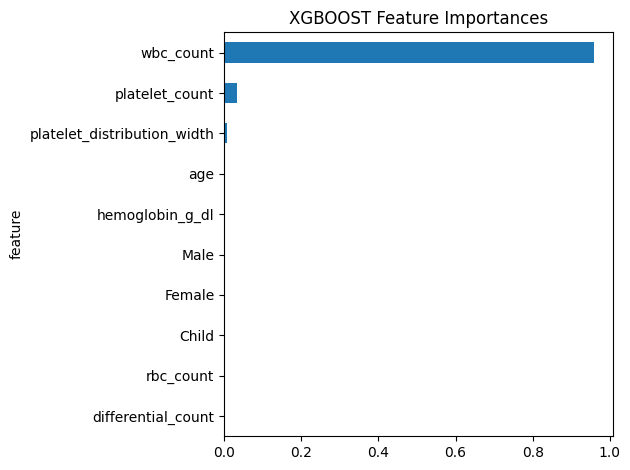

In [31]:
#Plotting features
import matplotlib.pyplot as plt
importances.sort_values('importance').plot(
    kind='barh', x='feature', y='importance', legend=False
)

plt.title('XGBOOST Feature Importances')
plt.tight_layout()
plt.show()

## KNN Classification
- K-Nearest Neighbors (KNN) is a simple non-parametric algorithm that classifies a new point by finding the K closest points in the training data (using Euclidean distance) and taking a majority vote of their labels.
- Simple to understand and implement, can capture non-linear relationships
- Slow prediction time, can suffer with high dimensional data

In [32]:
#Scaling the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
#Train the model
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

         0.0       0.66      0.50      0.57       104
         1.0       0.69      0.81      0.75       144

    accuracy                           0.68       248
   macro avg       0.68      0.66      0.66       248
weighted avg       0.68      0.68      0.67       248



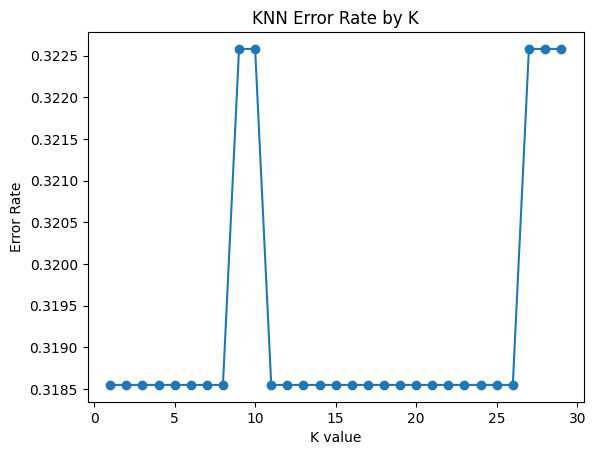

In [34]:
#Find optimal K
import matplotlib.pyplot as plt

error_rates = []
for k in range(1, 30):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    error_rates.append(1 - knn.score(X_test_scaled, y_test))

plt.plot(range(1, 30), error_rates, marker='o')
plt.xlabel('K value')
plt.ylabel('Error Rate')
plt.title('KNN Error Rate by K')
plt.show()

#Lets do best k = 5

In [35]:
#Refit with best K
knn_best = KNeighborsClassifier(n_neighbors=5)  # replace best_k with your chosen value
knn_best.fit(X_train_scaled, y_train)
y_pred_best = knn_best.predict(X_test_scaled)
print(classification_report(y_test, y_pred_best))
#about the same

              precision    recall  f1-score   support

         0.0       0.66      0.50      0.57       104
         1.0       0.69      0.81      0.75       144

    accuracy                           0.68       248
   macro avg       0.68      0.66      0.66       248
weighted avg       0.68      0.68      0.67       248



## Model Comparison

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#Summary Table
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    'Logistic Regression': y_pred,
    'Random Forest':       y_pred_rf,
    'XGBoost':             y_pred_xgb,
    'KNN':                 y_pred_best
}

results = []
for name, preds in models.items():
    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, preds), 3),
        'Precision': round(precision_score(y_test, preds), 3),
        'Recall':    round(recall_score(y_test, preds), 3),
        'F1 Score':  round(f1_score(y_test, preds), 3),
    })

results_df = pd.DataFrame(results).set_index('Model')
print(results_df)

                     Accuracy  Precision  Recall  F1 Score
Model                                                     
Logistic Regression     0.669      0.685   0.799     0.737
Random Forest           0.681      0.692   0.812     0.748
XGBoost                 0.677      0.688   0.812     0.745
KNN                     0.681      0.692   0.812     0.748



Full Comparison Table:
                     Accuracy  Precision  Recall  F1 Score    AUC
Model                                                            
Logistic Regression     0.669      0.685   0.799     0.737  0.631
Random Forest           0.681      0.692   0.812     0.748  0.668
XGBoost                 0.677      0.688   0.812     0.745  0.674
KNN                     0.681      0.692   0.812     0.748  0.651


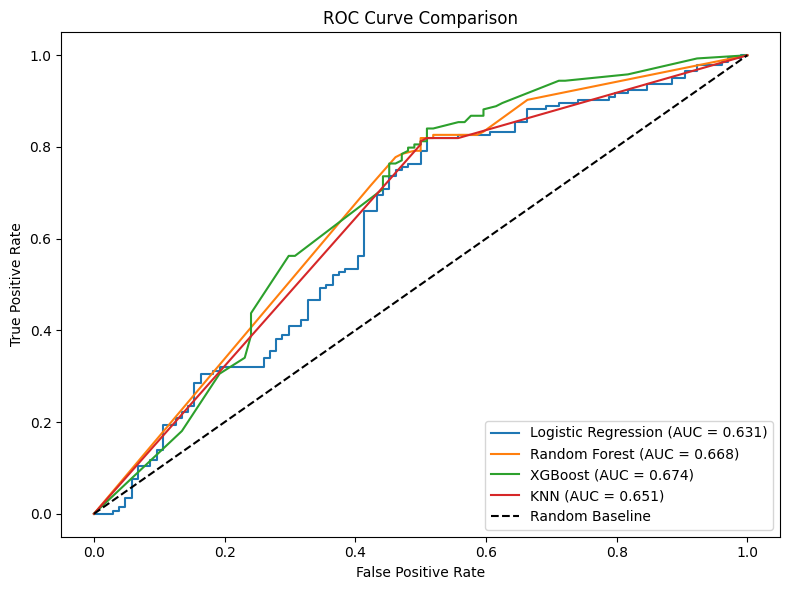

In [ ]:
# ROC Curves
# Get predicted probabilities for each model
proba_models = {
    'Logistic Regression': model.predict_proba(X_test)[:, 1],
    'Random Forest':       rf_model.predict_proba(X_test)[:, 1],
    'XGBoost':             xgb_model.predict_proba(X_test)[:, 1],
    'KNN':                 knn_best.predict_proba(X_test_scaled)[:, 1]
}

plt.figure(figsize=(8, 6))

for name, proba in proba_models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

# Add AUC to results table
auc_scores = {name: round(roc_auc_score(y_test, proba), 3)
              for name, proba in proba_models.items()}
results_df['AUC'] = pd.Series(auc_scores)
print("\nFull Comparison Table:")
print(results_df)

# Diagonal baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

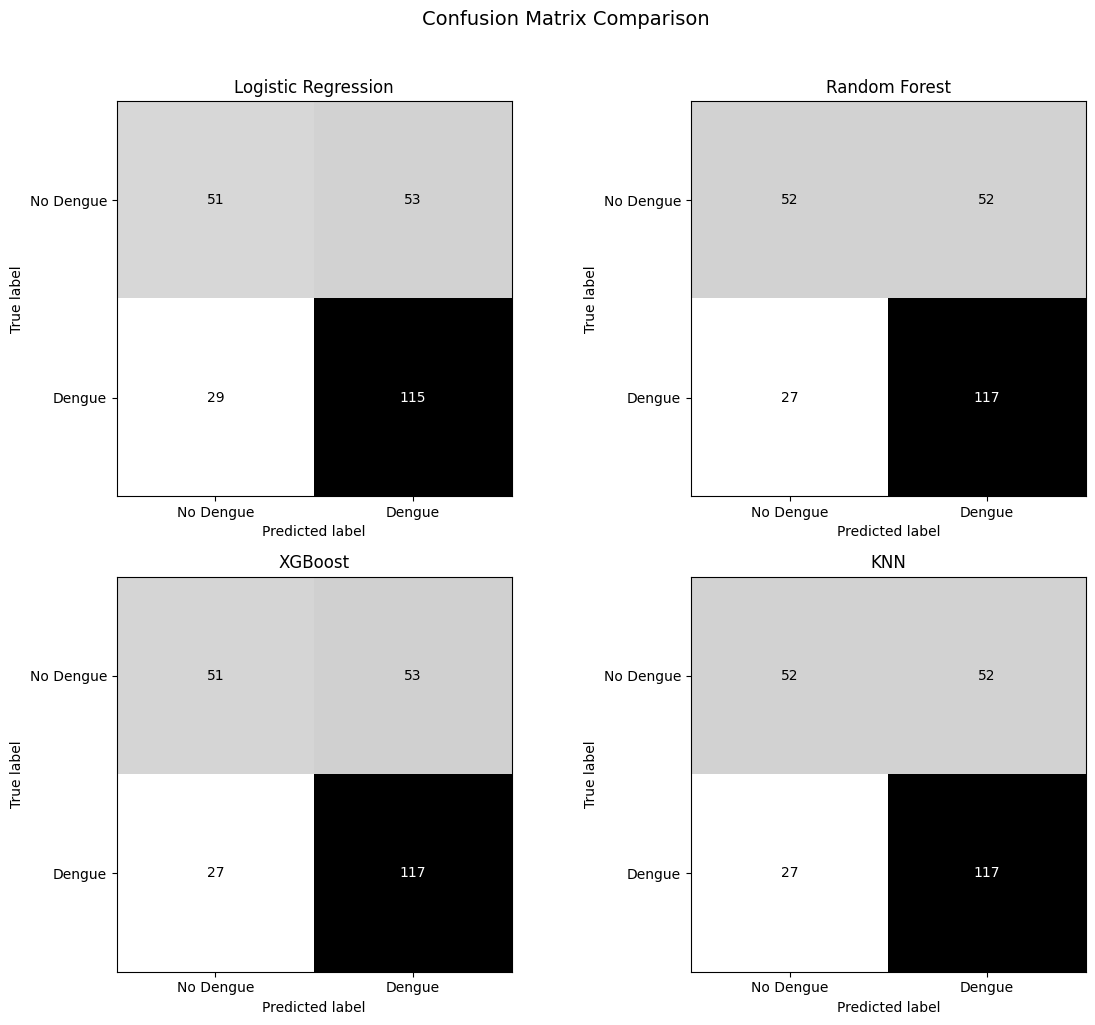

In [ ]:
# Confusion Matrices
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, preds) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Dengue', 'Dengue'])
    disp.plot(ax=ax, colorbar=False, cmap='Greys')
    ax.set_title(name)

plt.suptitle('Confusion Matrix Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

## Conclusion



